In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
from PIL import Image

## Train Test Split

In [10]:
train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    "train_data",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = train_gen.flow_from_directory(
    "train_data",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    "test_data",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


## Train Data Distribution

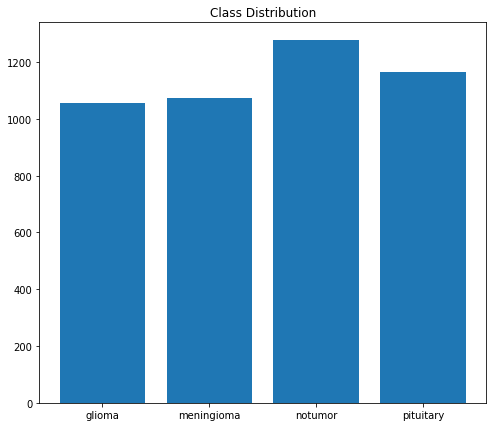

In [ ]:
classes = list(train_data.class_indices.keys())


counts =[]
for i ,c in enumerate(classes):
    counts.append( (train_data.labels==i).sum())

plt.figure(figsize=(8, 7))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.show()


## Test Data Distribution

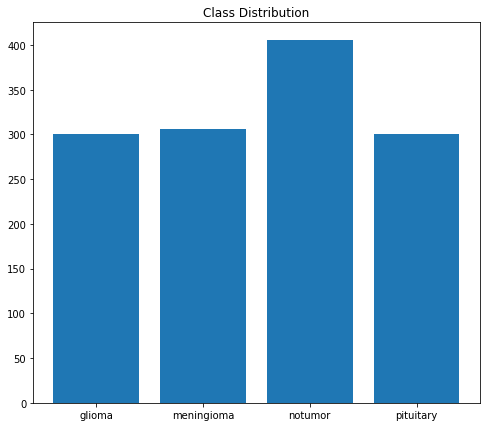

In [20]:
classes = list(test_data.class_indices.keys())


counts =[]
for i ,c in enumerate(classes):
    counts.append( (test_data.labels==i).sum())

plt.figure(figsize=(8, 7))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.show()


## Sample Images per Class Visualization

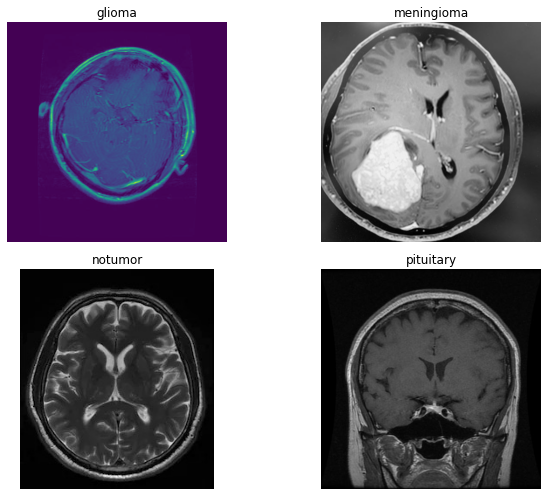

In [ ]:
plt.figure(figsize=(10, 7))

for i, c in enumerate(classes):
    
    for j, label in enumerate(train_data.labels):
        if label == i:
            img_path = train_data.filepaths[j]
            img = Image.open(img_path)
            plt.subplot(2, 2, i + 1)
            plt.imshow(img)
            plt.title(c)
            plt.axis("off")
            break


plt.tight_layout()
plt.show()
